# YJMob EDA: Home/Work Cells and Overture POIs

This notebook characterizes YJMob cells with Overture Maps POIs and correlates POI density/category features with the number of users inferred to live or work in each cell.

Home and work are inferred from repeated observations, not from ground-truth labels.

In [8]:
from __future__ import annotations

from pathlib import Path
from time import perf_counter

import duckdb
import geopandas as gpd
import h3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from shapely import wkt

from citybehavex.tessellation import load_category_mapping

sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("../../data/yjmob")
TRAJECTORY_PATH = DATA_DIR / "yjmob_wgs84_simple.parquet"
TESS_PATH = DATA_DIR / "yjmob_h3_tessellation.parquet"
CATEGORY_CACHE_PATH = DATA_DIR / "yjmob_overture_poi_categories_h3r8.parquet"
OVERTURE_INDEX_CACHE_PATH = DATA_DIR / "yjmob_overture_home_work_index_h3r8.parquet"

H3_RESOLUTION = 8
OVERTURE_RELEASE = "2026-05-20.0"
RUN_LIVE_OVERTURE_QUERY = False
RUN_LIVE_OVERTURE_INDEX_QUERY = False
POI_INDEX_ALPHA = 0.75
ADDRESS_INDEX_BETA = 1.0

assert TRAJECTORY_PATH.exists(), TRAJECTORY_PATH
assert TESS_PATH.exists(), TESS_PATH

## Load Sources

The trajectory table is large, so DuckDB reads selected columns directly from parquet. The Overture tessellation is the cached H3-resolution-8 POI table generated for YJMob.

In [9]:
con = duckdb.connect()
con.sql("INSTALL h3 FROM community; LOAD h3;")
con.sql("INSTALL spatial; LOAD spatial;")

traj_summary = con.sql(f"""
    SELECT
        COUNT(*) AS rows,
        COUNT(DISTINCT uid) AS users,
        MIN(timestamp) AS min_timestamp,
        MAX(timestamp) AS max_timestamp,
        MIN(lat) AS min_lat,
        MAX(lat) AS max_lat,
        MIN(lon) AS min_lon,
        MAX(lon) AS max_lon
    FROM read_parquet('{TRAJECTORY_PATH}')
""").df()

tessellation = pd.read_parquet(TESS_PATH)
display(traj_summary)
display(tessellation.head())
print(f"Tessellation cells: {len(tessellation):,}")

,rows,users,min_timestamp,max_timestamp,min_lat,max_lat,min_lon,max_lon
0,111535175,100000,2019-09-15,2019-11-28 23:30:00,34.666769,35.664487,136.61344,137.612506


,tile_id,lat,lng,cell_polygon_wkt,total_poi_count
0,882e60541dfffff,35.165013,136.904611,"POLYGON ((136.909047 35.162456, 136.909144 35....",3224
1,882e605403fffff,35.171851,136.909242,"POLYGON ((136.913678 35.169294, 136.913776 35....",2928
2,882e6054e9fffff,35.173095,136.882338,"POLYGON ((136.886774 35.170540, 136.886870 35....",2874
3,882e605415fffff,35.172266,136.900273,"POLYGON ((136.904709 35.169710, 136.904807 35....",2064
4,882e60540bfffff,35.164596,136.913580,"POLYGON ((136.918015 35.162039, 136.918114 35....",1595


Tessellation cells: 9,853


## Assign Observations to H3 Cells

The view below computes `h3_cell`, `hour`, and weekday flags without materializing the full 111M-row dataset in pandas.

In [10]:
con.sql(f"""
    CREATE OR REPLACE VIEW yjmob_observations AS
    SELECT
        uid,
        h3_latlng_to_cell_string(lat, lon, {H3_RESOLUTION}) AS h3_cell,
        CAST(FLOOR(t / 2) AS INTEGER) AS hour,
        CAST(d % 7 AS INTEGER) AS weekday,
        (d % 7 BETWEEN 1 AND 5) AS is_weekday
    FROM read_parquet('{TRAJECTORY_PATH}')
    WHERE lat IS NOT NULL AND lon IS NOT NULL
""")

assignment_quality = con.sql("""
    SELECT
        COUNT(*) AS rows,
        COUNT(*) FILTER (WHERE h3_cell IS NOT NULL) AS rows_with_h3,
        COUNT(DISTINCT uid) AS users,
        COUNT(DISTINCT h3_cell) AS observed_h3_cells
    FROM yjmob_observations
""").df()

display(assignment_quality)
display(con.sql("SELECT * FROM yjmob_observations LIMIT 5").df())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,rows,rows_with_h3,users,observed_h3_cells
0,111535175,111535175,100000,14651


,uid,h3_cell,hour,weekday,is_weekday
0,0,882e605187fffff,0,0,False
1,0,882e605187fffff,1,0,False
2,0,882e6051a3fffff,4,0,False
3,0,882e6051a3fffff,4,0,False
4,0,882e60518dfffff,9,0,False


## Infer Home and Work Cells

Home is the most frequent nighttime cell per user from 02:00-05:59. Work is the most frequent non-home weekday cell at 10:00 or from 14:00-16:59.

In [11]:
home_cells = con.sql("""
    WITH home_counts AS (
        SELECT uid, h3_cell, COUNT(*) AS records
        FROM yjmob_observations
        WHERE hour BETWEEN 2 AND 5
        GROUP BY uid, h3_cell
    ), ranked AS (
        SELECT
            uid,
            h3_cell AS home_cell,
            records AS home_records,
            ROW_NUMBER() OVER (
                PARTITION BY uid ORDER BY records DESC, h3_cell
            ) AS rn
        FROM home_counts
    )
    SELECT uid, home_cell, home_records
    FROM ranked
    WHERE rn = 1
""").df()

con.register("home_cells", home_cells)

work_cells = con.sql("""
    WITH work_counts AS (
        SELECT o.uid, o.h3_cell, COUNT(*) AS records
        FROM yjmob_observations o
        LEFT JOIN home_cells h ON o.uid = h.uid
        WHERE o.is_weekday
          AND (o.hour = 10 OR o.hour BETWEEN 14 AND 16)
          AND (h.home_cell IS NULL OR o.h3_cell <> h.home_cell)
        GROUP BY o.uid, o.h3_cell
    ), ranked AS (
        SELECT
            uid,
            h3_cell AS work_cell,
            records AS work_records,
            ROW_NUMBER() OVER (
                PARTITION BY uid ORDER BY records DESC, h3_cell
            ) AS rn
        FROM work_counts
    )
    SELECT uid, work_cell, work_records
    FROM ranked
    WHERE rn = 1
""").df()

home_users_by_cell = (
    home_cells.groupby("home_cell", as_index=False)
    .agg(home_users=("uid", "nunique"), home_records=("home_records", "sum"))
    .rename(columns={"home_cell": "h3_cell"})
)
work_users_by_cell = (
    work_cells.groupby("work_cell", as_index=False)
    .agg(work_users=("uid", "nunique"), work_records=("work_records", "sum"))
    .rename(columns={"work_cell": "h3_cell"})
)

cell_people = home_users_by_cell.merge(work_users_by_cell, on="h3_cell", how="outer").fillna(0)
for col in ["home_users", "home_records", "work_users", "work_records"]:
    cell_people[col] = cell_people[col].astype("int64")

print(f"Users with inferred home: {home_cells['uid'].nunique():,}")
print(f"Users with inferred work: {work_cells['uid'].nunique():,}")
print(f"Cells with home or work users: {len(cell_people):,}")
display(cell_people.sort_values(["home_users", "work_users"], ascending=False).head())

Users with inferred home: 94,078
Users with inferred work: 99,988
Cells with home or work users: 8,518


,h3_cell,home_users,home_records,work_users,work_records
5166,882e60cecbfffff,141,4394,724,26402
5135,882e60ce85fffff,128,7870,187,8273
4326,882e60c525fffff,118,3759,245,9907
5173,882e60cedbfffff,116,4328,1105,48106
4255,882e60c463fffff,107,5535,64,3327


## Enrich Cells with Cached Overture POI Counts

In [12]:
poi_cells = tessellation.rename(columns={"tile_id": "h3_cell", "lng": "lon"}).copy()
cell_features = cell_people.merge(poi_cells, on="h3_cell", how="outer")

for col in ["home_users", "home_records", "work_users", "work_records", "total_poi_count"]:
    cell_features[col] = cell_features[col].fillna(0)

count_cols = ["home_users", "home_records", "work_users", "work_records", "total_poi_count"]
cell_features[count_cols] = cell_features[count_cols].astype("int64")

cell_features["has_poi"] = cell_features["total_poi_count"].gt(0).astype("int64")
cell_features["log1p_total_poi_count"] = np.log1p(cell_features["total_poi_count"])
cell_features["home_work_ratio"] = cell_features["home_users"] / cell_features["work_users"].replace(0, np.nan)
cell_features["work_home_ratio"] = cell_features["work_users"] / cell_features["home_users"].replace(0, np.nan)

display(cell_features[["h3_cell", "home_users", "work_users", "total_poi_count", "has_poi"]].head())
display(cell_features[["home_users", "work_users", "total_poi_count"]].describe())

,h3_cell,home_users,work_users,total_poi_count,has_poi
0,882e60000dfffff,0,1,0,0
1,882e60002dfffff,1,0,0,0
2,882e600041fffff,3,1,0,0
3,882e600043fffff,6,4,0,0
4,882e600045fffff,2,5,0,0


,home_users,work_users,total_poi_count
count,13647.000000,13647.000000,13647.000000
mean,6.893676,7.326738,16.250385
std,11.769778,20.040550,68.049004
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,1.000000,2.000000
75%,9.000000,8.000000,12.000000
max,141.000000,1105.000000,3224.000000


## Optional Overture Category Enrichment

Set `RUN_LIVE_OVERTURE_QUERY = True` in the configuration cell to fetch category-level POIs from Overture S3 when the local cache is missing.

In [13]:
category_counts = None
category_feature_table = None

if CATEGORY_CACHE_PATH.exists():
    category_counts = pd.read_parquet(CATEGORY_CACHE_PATH)
    print(f"Loaded cached category counts from {CATEGORY_CACHE_PATH}")
elif RUN_LIVE_OVERTURE_QUERY:
    bbox = traj_summary.iloc[0]
    min_lon, min_lat = bbox["min_lon"], bbox["min_lat"]
    max_lon, max_lat = bbox["max_lon"], bbox["max_lat"]
    con.sql("SET s3_region = 'us-west-2';")
    category_counts = con.sql(f"""
        SELECT
            h3_latlng_to_cell_string(ST_Y(geometry), ST_X(geometry), {H3_RESOLUTION}) AS h3_cell,
            categories.primary AS primary_category,
            COUNT(*) AS poi_count
        FROM read_parquet(
            's3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme=places/type=place/*',
            filename=true,
            hive_partitioning=1
        )
        WHERE bbox.xmin BETWEEN {min_lon} AND {max_lon}
          AND bbox.ymin BETWEEN {min_lat} AND {max_lat}
        GROUP BY h3_cell, primary_category
    """).df()
    category_counts.to_parquet(CATEGORY_CACHE_PATH, index=False)
    print(f"Saved category cache to {CATEGORY_CACHE_PATH}")
else:
    print(
        "No category cache found and RUN_LIVE_OVERTURE_QUERY is False. "
        "Continuing with cached total POI counts only."
    )

if category_counts is not None and not category_counts.empty:
    category_map = load_category_mapping()
    category_counts["purpose"] = category_counts["primary_category"].map(category_map).fillna("OTHER")

    top_categories = (
        category_counts.groupby("primary_category")["poi_count"].sum()
        .sort_values(ascending=False)
        .head(20)
        .index
        .tolist()
    )

    category_wide = (
        category_counts[category_counts["primary_category"].isin(top_categories)]
        .pivot_table(index="h3_cell", columns="primary_category", values="poi_count", aggfunc="sum", fill_value=0)
        .add_prefix("cat_")
        .reset_index()
    )
    purpose_wide = (
        category_counts.pivot_table(index="h3_cell", columns="purpose", values="poi_count", aggfunc="sum", fill_value=0)
        .add_prefix("purpose_")
        .reset_index()
    )
    category_feature_table = category_wide.merge(purpose_wide, on="h3_cell", how="outer").fillna(0)
    cell_features = cell_features.merge(category_feature_table, on="h3_cell", how="left")

    category_cols = [c for c in cell_features.columns if c.startswith("cat_") or c.startswith("purpose_")]
    cell_features[category_cols] = cell_features[category_cols].fillna(0).astype("int64")
    display(category_counts.sort_values("poi_count", ascending=False).head())
    print(f"Added {len(category_cols):,} category/purpose POI features.")

No category cache found and RUN_LIVE_OVERTURE_QUERY is False. Continuing with cached total POI counts only.


## Overture-Only Home/Work Heuristic

Approach 1 builds a rule-based employment-to-residential index from Overture-derived signals only. Places are available from the cached tessellation; Buildings and Addresses are fetched and cached only when `RUN_LIVE_OVERTURE_INDEX_QUERY = True`.

Live benchmark in this workspace for the YJMob bbox and Overture `2026-05-20.0`: Buildings count scanned 4,398,023 features across 11,306 H3 cells in 100.31s; Addresses count scanned 2,747,129 features across 8,403 H3 cells in 12.21s.

In [ ]:
def minmax(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").fillna(0).astype(float)
    lo, hi = values.min(), values.max()
    if hi <= lo:
        return pd.Series(0.0, index=values.index)
    return (values - lo) / (hi - lo)


def timed_sql_df(label: str, sql: str) -> tuple[pd.DataFrame, float]:
    start = perf_counter()
    df = con.sql(sql).df()
    seconds = perf_counter() - start
    print(f"{label}: {len(df):,} rows in {seconds:.2f}s")
    return df, seconds


timing_rows = []
start = perf_counter()
places_by_cell = poi_cells[["h3_cell", "total_poi_count"]].rename(columns={"total_poi_count": "place_count"}).copy()
timing_rows.append({"layer": "places_cached", "seconds": perf_counter() - start, "rows": len(places_by_cell)})

if OVERTURE_INDEX_CACHE_PATH.exists():
    overture_index_features = pd.read_parquet(OVERTURE_INDEX_CACHE_PATH)
    print(f"Loaded cached Overture index features from {OVERTURE_INDEX_CACHE_PATH}")
elif RUN_LIVE_OVERTURE_INDEX_QUERY:
    bbox = traj_summary.iloc[0]
    min_lon, min_lat = bbox["min_lon"], bbox["min_lat"]
    max_lon, max_lat = bbox["max_lon"], bbox["max_lat"]
    con.sql("INSTALL httpfs; LOAD httpfs; SET s3_region = 'us-west-2';")

    buildings_by_cell, building_seconds = timed_sql_df("buildings", f"""
        SELECT
            h3_latlng_to_cell_string(
                ST_Y(ST_Centroid(geometry)),
                ST_X(ST_Centroid(geometry)),
                {H3_RESOLUTION}
            ) AS h3_cell,
            COUNT(*) AS building_count
        FROM read_parquet(
            's3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme=buildings/type=*/*',
            filename=true,
            hive_partitioning=1
        )
        WHERE bbox.xmin BETWEEN {min_lon} AND {max_lon}
          AND bbox.ymin BETWEEN {min_lat} AND {max_lat}
        GROUP BY h3_cell
    """)
    timing_rows.append({"layer": "buildings_live", "seconds": building_seconds, "rows": len(buildings_by_cell)})

    addresses_by_cell, address_seconds = timed_sql_df("addresses", f"""
        SELECT
            h3_latlng_to_cell_string(ST_Y(geometry), ST_X(geometry), {H3_RESOLUTION}) AS h3_cell,
            COUNT(*) AS address_count
        FROM read_parquet(
            's3://overturemaps-us-west-2/release/{OVERTURE_RELEASE}/theme=addresses/type=*/*',
            filename=true,
            hive_partitioning=1
        )
        WHERE bbox.xmin BETWEEN {min_lon} AND {max_lon}
          AND bbox.ymin BETWEEN {min_lat} AND {max_lat}
        GROUP BY h3_cell
    """)
    timing_rows.append({"layer": "addresses_live", "seconds": address_seconds, "rows": len(addresses_by_cell)})

    overture_index_features = places_by_cell.merge(buildings_by_cell, on="h3_cell", how="outer").merge(addresses_by_cell, on="h3_cell", how="outer")
    overture_index_features.to_parquet(OVERTURE_INDEX_CACHE_PATH, index=False)
    print(f"Saved Overture index features to {OVERTURE_INDEX_CACHE_PATH}")
else:
    overture_index_features = places_by_cell.copy()
    overture_index_features["building_count"] = 0
    overture_index_features["address_count"] = 0
    print(
        "Using cached Places counts only. Set RUN_LIVE_OVERTURE_INDEX_QUERY = True "
        "to count and time Overture Buildings and Addresses."
    )

for col in ["place_count", "building_count", "address_count"]:
    if col not in overture_index_features.columns:
        overture_index_features[col] = 0
    overture_index_features[col] = overture_index_features[col].fillna(0).astype("int64")

place_scaled = minmax(overture_index_features["place_count"])
building_scaled = minmax(overture_index_features["building_count"])
address_scaled = minmax(overture_index_features["address_count"])

overture_index_features["overture_work_score"] = minmax(building_scaled + POI_INDEX_ALPHA * place_scaled)
overture_index_features["overture_home_score"] = minmax(address_scaled + 0.5 * (1.0 - place_scaled))
overture_index_features["overture_employment_residential_index"] = (
    overture_index_features["overture_work_score"]
    / (overture_index_features["overture_home_score"] + 0.05 * ADDRESS_INDEX_BETA)
)

timing_df = pd.DataFrame(timing_rows)
display(timing_df)
display(overture_index_features.sort_values("overture_employment_residential_index", ascending=False).head())

index_cols = [
    "h3_cell",
    "place_count",
    "building_count",
    "address_count",
    "overture_work_score",
    "overture_home_score",
    "overture_employment_residential_index",
]
cell_features = cell_features.merge(overture_index_features[index_cols], on="h3_cell", how="left")
cell_features[index_cols[1:]] = cell_features[index_cols[1:]].fillna(0)

In [ ]:
def validation_metrics(df: pd.DataFrame, prediction: str, target: str) -> dict[str, float | str | int]:
    pair = df[[prediction, target]].replace([np.inf, -np.inf], np.nan).dropna()
    row = {"prediction": prediction, "target": target, "n": len(pair)}
    if len(pair) < 3 or pair[prediction].nunique() < 2 or pair[target].nunique() < 2:
        return row
    row["pearson_r"] = stats.pearsonr(pair[prediction], pair[target]).statistic
    row["spearman_r"] = stats.spearmanr(pair[prediction], pair[target]).statistic
    denom = np.linalg.norm(pair[prediction]) * np.linalg.norm(pair[target])
    row["cosine_similarity"] = float(np.dot(pair[prediction], pair[target]) / denom) if denom else np.nan

    threshold = pair[target].quantile(0.80)
    hotspot = pair[target].ge(threshold).astype(int)
    if hotspot.nunique() == 2:
        from sklearn.metrics import average_precision_score, roc_auc_score

        row["roc_auc_top20"] = roc_auc_score(hotspot, pair[prediction])
        row["average_precision_top20"] = average_precision_score(hotspot, pair[prediction])
    return row


overture_validation = pd.DataFrame([
    validation_metrics(cell_features, "overture_home_score", "home_users"),
    validation_metrics(cell_features, "overture_work_score", "work_users"),
    validation_metrics(cell_features, "overture_employment_residential_index", "work_users"),
    validation_metrics(cell_features, "place_count", "work_users"),
    validation_metrics(cell_features, "place_count", "home_users"),
]).sort_values("spearman_r", ascending=False, na_position="last")

display(overture_validation)
best_row = overture_validation.dropna(subset=["spearman_r"]).head(1)
if not best_row.empty:
    best = best_row.iloc[0]
    print(
        f"Best Overture-only proxy by Spearman correlation: {best['prediction']} -> "
        f"{best['target']} (rho={best['spearman_r']:.3f})."
    )

## Correlation Analysis

In [14]:
def correlation_rows(df: pd.DataFrame, features: list[str], targets: list[str]) -> pd.DataFrame:
    rows = []
    for feature in features:
        for target in targets:
            pair = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
            if len(pair) < 3 or pair[feature].nunique() < 2 or pair[target].nunique() < 2:
                continue
            pearson_r, pearson_p = stats.pearsonr(pair[feature], pair[target])
            spearman_r, spearman_p = stats.spearmanr(pair[feature], pair[target])
            rows.append({
                "feature": feature,
                "target": target,
                "n": len(pair),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p,
            })
    out = pd.DataFrame(rows)
    if not out.empty:
        out["abs_spearman_r"] = out["spearman_r"].abs()
        out = out.sort_values(["target", "abs_spearman_r"], ascending=[True, False]).reset_index(drop=True)
    return out

base_features = [
    "total_poi_count",
    "has_poi",
    "log1p_total_poi_count",
    "place_count",
    "building_count",
    "address_count",
    "overture_work_score",
    "overture_home_score",
    "overture_employment_residential_index",
]
base_features = [c for c in base_features if c in cell_features.columns]
optional_features = [c for c in cell_features.columns if c.startswith("cat_") or c.startswith("purpose_")]
feature_cols = base_features + optional_features
target_cols = ["home_users", "work_users"]

correlations = correlation_rows(cell_features, feature_cols, target_cols)
display(correlations)

,feature,target,n,pearson_r,pearson_p,spearman_r,spearman_p,abs_spearman_r
0,has_poi,home_users,13647,-0.055704,7.425530e-11,-0.292072,1.487823e-266,0.292072
1,total_poi_count,home_users,13647,0.005297,5.360814e-01,-0.150109,1.347068e-69,0.150109
2,log1p_total_poi_count,home_users,13647,0.050708,3.084358e-09,-0.150109,1.347068e-69,0.150109
3,has_poi,work_users,13647,-0.018995,2.648792e-02,-0.276987,7.459093e-239,0.276987
4,total_poi_count,work_users,13647,0.030329,3.948438e-04,-0.131346,1.417902e-53,0.131346
5,log1p_total_poi_count,work_users,13647,0.066712,6.124659e-15,-0.131346,1.417902e-53,0.131346


## Visualizations

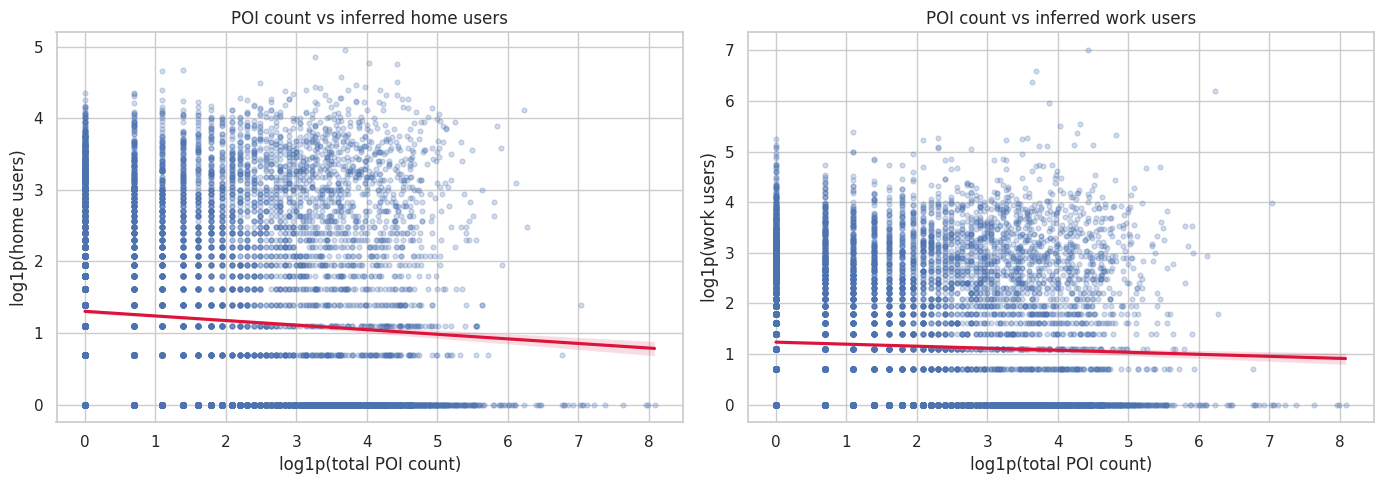

In [15]:
plot_df = cell_features.copy()
plot_df["log1p_home_users"] = np.log1p(plot_df["home_users"])
plot_df["log1p_work_users"] = np.log1p(plot_df["work_users"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
sns.regplot(data=plot_df, x="log1p_total_poi_count", y="log1p_home_users", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "crimson"}, ax=axes[0])
axes[0].set_title("POI count vs inferred home users")
axes[0].set_xlabel("log1p(total POI count)")
axes[0].set_ylabel("log1p(home users)")

sns.regplot(data=plot_df, x="log1p_total_poi_count", y="log1p_work_users", scatter_kws={"alpha": 0.25, "s": 12}, line_kws={"color": "crimson"}, ax=axes[1])
axes[1].set_title("POI count vs inferred work users")
axes[1].set_xlabel("log1p(total POI count)")
axes[1].set_ylabel("log1p(work users)")

plt.tight_layout()

In [16]:
display(cell_features.sort_values("home_users", ascending=False)[["h3_cell", "home_users", "work_users", "total_poi_count"]].head(15))
display(cell_features.sort_values("work_users", ascending=False)[["h3_cell", "home_users", "work_users", "total_poi_count"]].head(15))
display(cell_features.sort_values("total_poi_count", ascending=False)[["h3_cell", "home_users", "work_users", "total_poi_count"]].head(15))

,h3_cell,home_users,work_users,total_poi_count
7924,882e60cecbfffff,141,724,39
7893,882e60ce85fffff,128,187,25
7076,882e60c525fffff,118,245,55
7931,882e60cedbfffff,116,1105,82
7005,882e60c463fffff,107,64,3
7064,882e60c509fffff,105,74,2
7653,882e60cc11fffff,97,101,37
6686,882e60c095fffff,90,54,82
2105,882e601b6bfffff,88,104,11
7129,882e60c5adfffff,86,166,46


,h3_cell,home_users,work_users,total_poi_count
7931,882e60cedbfffff,116,1105,82
7924,882e60cecbfffff,141,724,39
7084,882e60c537fffff,72,584,37
7930,882e60ced9fffff,60,490,508
7932,882e60ceddfffff,30,384,47
7926,882e60ced1fffff,28,253,74
7076,882e60c525fffff,118,245,55
6024,882e608f23fffff,60,216,2
7927,882e60ced3fffff,75,214,71
7929,882e60ced7fffff,34,205,123


,h3_cell,home_users,work_users,total_poi_count
3773,882e60541dfffff,0,0,3224
3761,882e605403fffff,0,0,2928
3855,882e6054e9fffff,0,0,2874
3769,882e605415fffff,0,0,2064
3765,882e60540bfffff,0,0,1595
3770,882e605417fffff,0,0,1374
3768,882e605413fffff,0,0,1237
3771,882e605419fffff,0,0,1166
3767,882e605411fffff,0,0,1160
4025,882e6056adfffff,3,53,1132


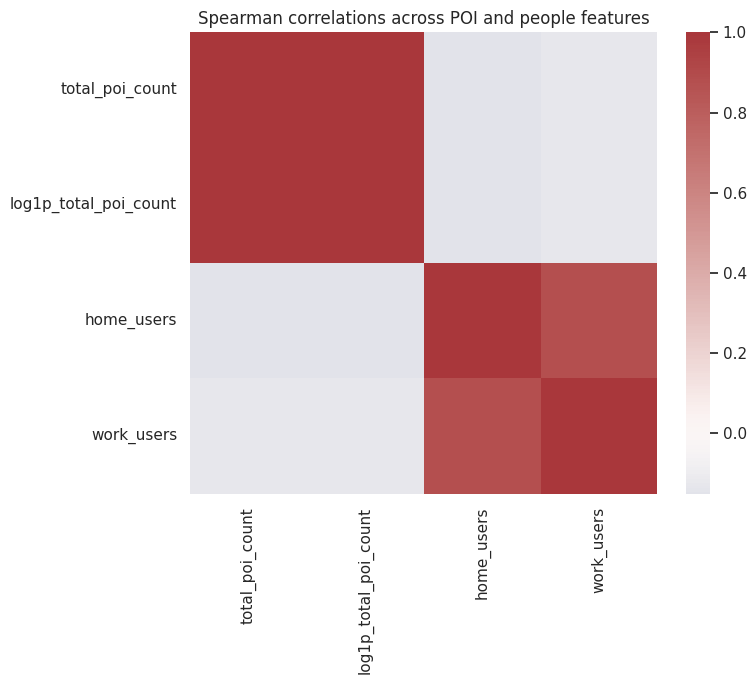

In [17]:
heatmap_features = base_features + optional_features[:20] + target_cols
heatmap_features = [c for c in heatmap_features if c in cell_features.columns]

if len(heatmap_features) >= 3:
    corr_matrix = cell_features[heatmap_features].corr(method="spearman")
    plt.figure(figsize=(max(8, len(heatmap_features) * 0.45), 7))
    sns.heatmap(corr_matrix, cmap="vlag", center=0, square=False)
    plt.title("Spearman correlations across POI and people features")
    plt.tight_layout()
else:
    print("Not enough numeric features for a heatmap.")

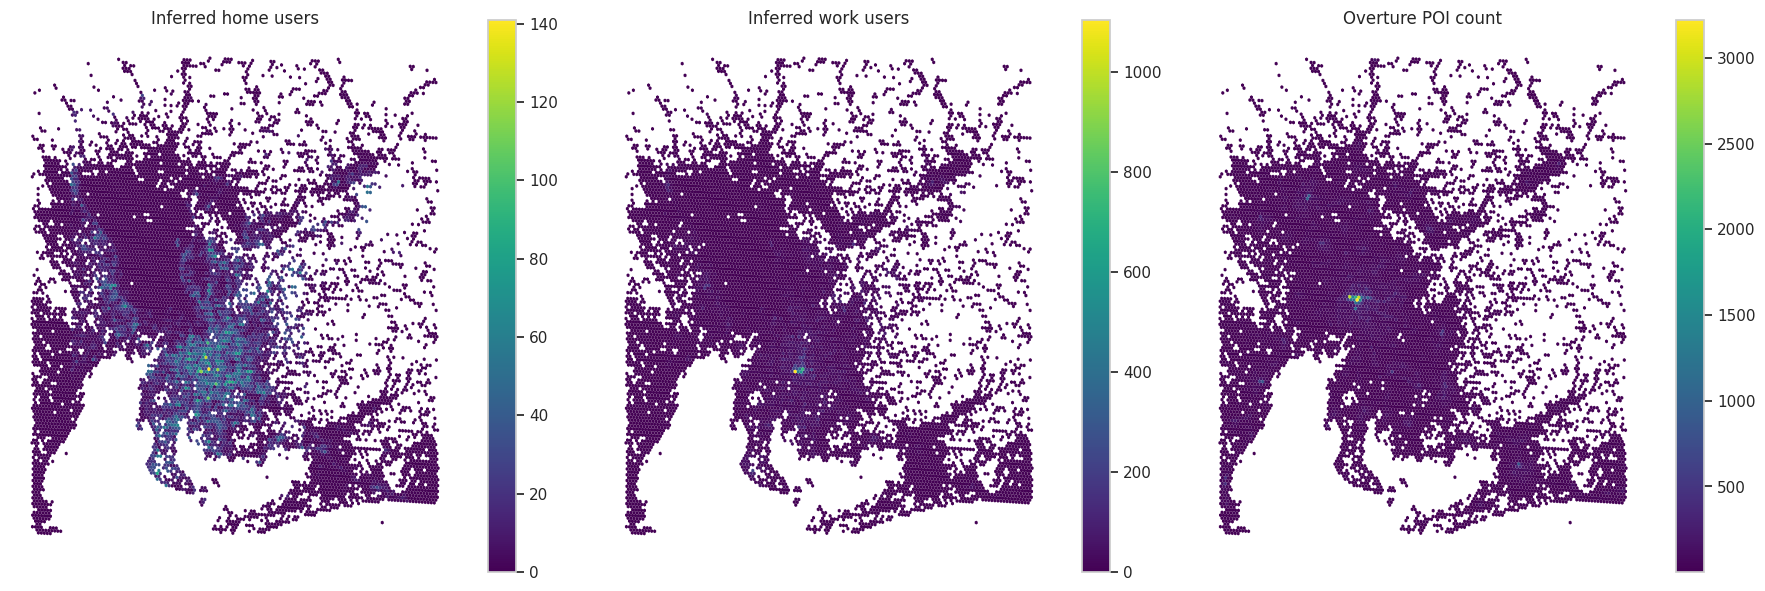

In [18]:
map_df = cell_features.dropna(subset=["cell_polygon_wkt"]).copy()
map_df["geometry"] = map_df["cell_polygon_wkt"].map(wkt.loads)
cell_gdf = gpd.GeoDataFrame(map_df, geometry="geometry", crs="EPSG:4326")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, column, title in [
    (axes[0], "home_users", "Inferred home users"),
    (axes[1], "work_users", "Inferred work users"),
    (axes[2], "total_poi_count", "Overture POI count"),
]:
    cell_gdf.plot(column=column, cmap="viridis", linewidth=0, legend=True, ax=ax)
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()

## Interpretation Notes

- A positive POI/work correlation suggests Overture-dense cells tend to attract inferred work locations.
- A positive POI/home correlation suggests residential inference is concentrated near amenity or business density, or that the grid cell is mixed-use.
- A weak or negative POI/home correlation is plausible because Overture `places` mostly describes businesses and amenities, not residential buildings.
- Category-level correlations are only available when the optional Overture category cache has been created.
- Home and work labels are inferred from repeated timestamped observations. They should be interpreted as behavioral anchors, not survey-confirmed home or workplace addresses.